![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

# CSCK506 Deep Learning: END-MODULE ASSIGNMENT

Pneumonia is an inflammatory condition of the lungs and remains a common and potentially serious disease worldwide. Early and accurate diagnosis is essential for effective treatment, yet traditional methods—such as manual interpretation of chest X-ray images—can be time-consuming and subject to variability among clinicians.

This project explores automated deep learning approaches to detect pneumonia from medical images, with the goal of assisting and improving diagnostic processes.

### Objectives
- Develop models capable of accurately classifying chest X-ray images as NORMAL or PNEUMONIA
- Compare baseline and advanced deep learning approaches
- Evaluate the impact of preprocessing, augmentation, and transfer learning
- Optimize model performance using appropriate metrics (Accuracy, AUC, Precision, Recall, F1-score)


### Project Structure

The project is organized into three main notebooks, each focusing on a key stage of the machine learning pipeline:

1. Exploratory Data Analysis (EDA)
- Understand dataset structure and distribution
- Visualize class imbalance and sample images
- Identify potential challenges (noise, variability, imbalance)

2. Preprocessing & Models (Baselines and Tuned)

- Data preprocessing and pipeline setup
- Model experimentation with three baselines:

        i. Baseline CNN (no augmentation)
        ii. Baseline CNN with data augmentation
        iii. Tuned CNN (optimized hyperparameters)

The goal is to establish strong reference models and understand the impact of basic improvements.

3. Transfer Learning & Model Comparison
- Use pretrained models VGG16 for feature extraction and fine-tuning
- Improve performance through transfer learning
- Compare all models using standardized evaluation metrics
- Analyze trade-offs between performance and complexity

### Expected Outcomes

By the end of this project, we aim to:

- Identify the most effective modeling approach for pneumonia detection
- Quantify the benefits of augmentation and transfer learning
- Provide a clear comparison of all models

Overall, the goal is to develop a reliable and interpretable diagnostic support tool.

In [109]:
import os
import sys
import json
import random
import pathlib
import importlib.util
import subprocess
import importlib
from datetime import datetime

# Local environments can miss optional tuning deps required by keras-tuner.
for pkg_name in ["tensorboard", "keras-tuner"]:
    if importlib.util.find_spec(pkg_name.replace("-", "_")) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg_name], check=False)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
import keras_tuner as kt
from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.19.0
Keras: 3.13.2


In [110]:
USE_COLAB = True
USE_KAGGLE = False  # Set True when running on Kaggle

In [111]:
# Configuration
if USE_KAGGLE:

    KAGGLE_HELPERS_PARENT = "/kaggle/input/datasets/omosaad/helpers"
    KAGGLE_HELPERS_DIR = "/kaggle/input/datasets/omosaad/helpers/helpers"

    DATASET_ROOT = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/"
    SAVE_DIR = pathlib.Path("/kaggle/working/saved_models")

    try:
        from helpers import data_utils, model_utils, training_utils, visualization
    except ModuleNotFoundError:
        for p in [KAGGLE_HELPERS_PARENT, KAGGLE_HELPERS_DIR]:
            if os.path.isdir(p) and p not in sys.path:
                sys.path.append(p)
        from helpers import data_utils, model_utils, training_utils, visualization

elif USE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    DATASET_ROOT = "/content/drive/MyDrive/x-ray-dataset/"
    SAVE_DIR = pathlib.Path("/content/drive/MyDrive/saved_models")

    # Point to the folder containing the 'helpers' folder
    sys.path.append('/content/drive/MyDrive/Colab Notebooks')

    from helpers import data_utils, model_utils, training_utils, visualization

    importlib.reload(data_utils)
    importlib.reload(model_utils)
    importlib.reload(training_utils)
    importlib.reload(visualization)

else:
    DATASET_ROOT = "dataset"
    SAVE_DIR = pathlib.Path("saved_models")

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "val")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.1
AUTOTUNE   = tf.data.AUTOTUNE

for split_path in [TRAIN_DIR, TEST_DIR]:
    if not os.path.isdir(split_path):
        raise FileNotFoundError(f"Missing directory: {split_path}")

SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Model checkpoint paths
TEACHER_CHECKPOINT_PATH  = SAVE_DIR / "vgg16_frozen_best_checkpoint.keras"
FINETUNE_CHECKPOINT_PATH = SAVE_DIR / "vgg16_finetuned_best_checkpoint.keras"

runtime_name = "Kaggle" if USE_KAGGLE else ("Google Colab" if USE_COLAB else "Local")
print(f"Environment:  {runtime_name}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Model artifacts will be stored in: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment:  Google Colab
Dataset root: /content/drive/MyDrive/x-ray-dataset/
Model artifacts will be stored in: /content/drive/MyDrive/saved_models


In [112]:
# Notebook context
print(f"Runtime mode selected via USE_COLAB={USE_COLAB}.")

Runtime mode selected via USE_COLAB=True.


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## Transfer Learning and Distillation Experiments Notebook

This notebook implements VGG16 feature extraction and knowledge distillation using the tuned baseline architecture as the student.

<hr style="height:6px;background-color:blue;border:none;">

### Phase 1 - Data Loading

In [113]:
# Bind a notebook-local saver without redefining utility functions here.
save_model_with_meta = training_utils.make_model_saver(SAVE_DIR)


In [114]:
# Gather train(+optional original val) and test paths/labels
all_train_paths, all_train_labels, test_paths, test_labels = data_utils.gather_split_paths_labels(
    TRAIN_DIR,
    TEST_DIR,
    val_dir=VAL_DIR,
)

if len(np.unique(all_train_labels)) < 2:
    raise ValueError("Both NORMAL and PNEUMONIA classes must exist in the training pool.")

print(f"Training pool size (train + optional original val): {len(all_train_paths)} images")
print(f"  NORMAL={(all_train_labels==0).sum()}, PNEUMONIA={(all_train_labels==1).sum()}")
print(f"Test set size: {len(test_paths)} images")


Training pool size (train + optional original val): 5232 images
  NORMAL=1349, PNEUMONIA=3883
Test set size: 624 images


In [115]:
data_augmentation = data_utils.build_data_augmentation(
    rotation=30,
    width_shift=0.1,
    height_shift=0.1,
    shear=0.2,
    zoom=0.2,
)

# Build train/val/test datasets with raw [0, 255] images.
# VGG16 preprocessing is applied internally by the model after augmentation —
# do NOT pass a preprocess_fn here to avoid double-preprocessing.
train_ds, val_ds, test_ds, ds_meta = data_utils.build_train_val_test_datasets(
    all_train_paths,
    all_train_labels,
    test_paths,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    seed=42,
    autotune=AUTOTUNE,
)

# Paper-aligned class weights: penalise missed pneumonia cases 4x
# (clinical priority to minimise false negatives), matching the paper's
# explicit value of weight=4 for the PNEUMONIA class.
class_weights = {0: 1.0, 1: 4.0}

print(f"Train split -> NORMAL={ds_meta['normal_count']}, PNEUMONIA={ds_meta['pneumonia_count']}")
print(f"Validation size: {len(ds_meta['val_labels'])}")
print("Class weights:", class_weights)
print("Datasets are ready.")


Train split -> NORMAL=1214, PNEUMONIA=3494
Validation size: 524
Class weights: {0: 1.0, 1: 4.0}
Datasets are ready.


<hr style="height:6px;background-color:blue;border:none;">

### Phase 2 - VGG16 Training

In [116]:
# ── Phase 1: Feature extraction with frozen VGG16 base ──────────────────────
# Raw [0,255] datasets are used; the model applies VGG16 preprocessing
# internally after augmentation (no double-preprocessing).

teacher_model = model_utils.build_vgg16_model(
    img_size=IMG_SIZE,
    augmentation_layer=data_augmentation,
    dense_units=128,
    dense_units_2=64,
    dropout=0.5,
    dropout_2=0.3,
    learning_rate=1e-4,
    freeze_base=True,
    name="vgg16_frozen",
)
teacher_model.summary(show_trainable=True)

teacher_callbacks = training_utils.get_training_callbacks(
    checkpoint_path=TEACHER_CHECKPOINT_PATH,
    patience=7,
    monitor="val_auc",
)

teacher_history = teacher_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=teacher_callbacks,
    class_weight=class_weights,
    verbose=1,
)
print(f"Phase 1 complete. Best checkpoint saved to: {TEACHER_CHECKPOINT_PATH}")


Model: "vgg16_frozen"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_19    │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ data_augmentation │ (None, 224,     │         0 │ input_layer_1… │   -   │
│ (Sequential)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_18       │ (None, 224,     │         0 │ data_augmenta… │   -   │
│ (GetItem)         │ 224)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_19       │ (None, 224,     │         0 │ data_augmenta… │   -   │
│ (GetItem)         │ 224)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_20       │ (None, 224,     │         0 │ data_augmenta… │   -   │
│ (GetItem)         │ 224)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stack_6 (Stack)   │ (None, 224,     │         0 │ get_item_18[0… │   -   │
│                   │ 224, 3)         │           │ get_item_19[0… │       │
│                   │                 │           │ get_item_20[0… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ add_6 (Add)       │ (None, 224,     │         0 │ stack_6[0][0]  │   -   │
│                   │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ vgg16             │ (None, 7, 7,    │ 14,714,6… │ add_6[0][0]    │   N   │
│ (Functional)      │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 512)     │         0 │ vgg16[0][0]    │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_18 (Dense)  │ (None, 128)     │    65,664 │ global_averag… │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 128)     │       512 │ dense_18[0][0] │   Y   │
│ (BatchNormalizat… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_12        │ (None, 128)     │         0 │ batch_normali… │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_19 (Dense)  │ (None, 64)      │     8,256 │ dropout_12[0]… │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 64)      │       256 │ dense_19[0][0] │   Y   │
│ (BatchNormalizat… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_13        │ (None, 64)      │         0 │ batch_normali… │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_20 (Dense)  │ (None, 1)       │        65 │ dropout_13[0]… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 14,789,441 (56.42 MB)

 Trainable params: 74,369 (290.50 KB)

 Non-trainable params: 14,715,072 (56.13 MB)

Epoch 1/50
147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.5664 - auc: 0.5918 - loss: 2.6444 - precision: 0.7960 - recall: 0.5674
Epoch 1: val_auc improved from None to 0.88773, saving model to /content/drive/MyDrive/saved_models/vgg16_frozen_best_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/saved_models/vgg16_frozen_best_checkpoint.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 40s 242ms/step - accuracy: 0.6105 - auc: 0.6655 - loss: 2.4487 - precision: 0.8230 - recall: 0.6053 - val_accuracy: 0.3550 - val_auc: 0.8877 - val_loss: 1.7560 - val_precision: 0.9811 - val_recall: 0.1337 - learning_rate: 1.0000e-04
Epoch 2/50
147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7139 - auc: 0.8011 - loss: 2.0312 - precision: 0.8964 - recall: 0.6995
Epoch 2: val_auc improved from 0.88773 to 0.92625, saving model to /content/drive/MyDrive/saved_models/vgg16_frozen_best_checkpoint.keras

Epoch 2: finished saving model to /content/drive/MyDrive/saved_models/vgg16_froze

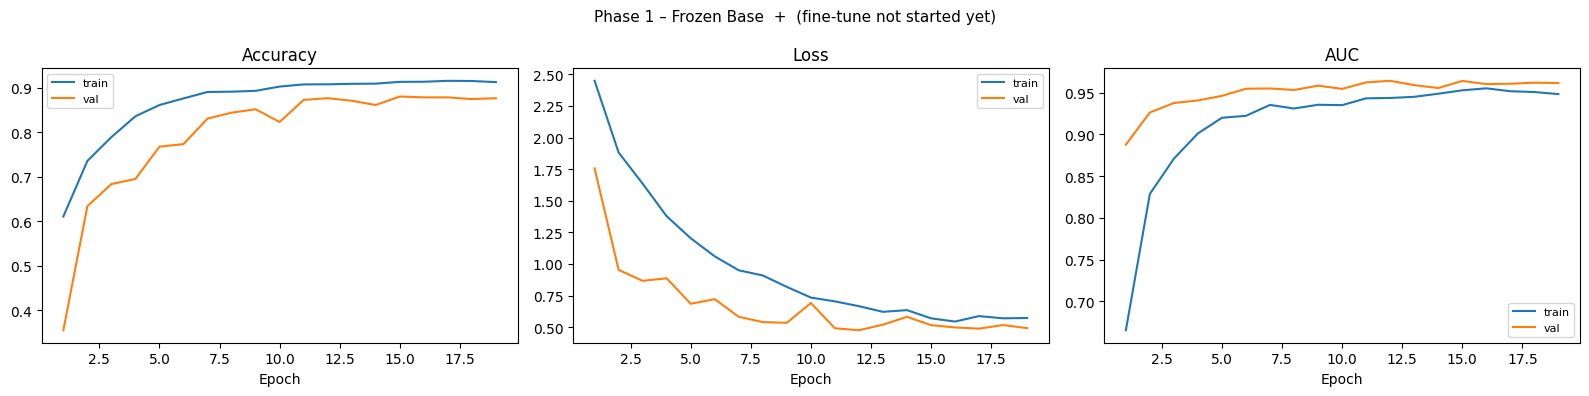

Unfrozen: {'block5_conv3', 'block5_conv2', 'block5_pool', 'block5_conv1'}
Trainable params after unfreeze: 7,153,793
Epoch 1/20
146/148 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9194 - auc: 0.9544 - loss: 0.5930 - precision: 0.9378 - recall: 0.9559
Epoch 1: val_auc improved from None to 0.94318, saving model to /content/drive/MyDrive/saved_models/vgg16_finetuned_best_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/saved_models/vgg16_finetuned_best_checkpoint.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9174 - auc: 0.9548 - loss: 0.5828 - precision: 0.9323 - recall: 0.9582 - val_accuracy: 0.7767 - val_auc: 0.9432 - val_loss: 1.1336 - val_precision: 0.9928 - val_recall: 0.7044 - learning_rate: 1.0000e-05
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9357 - auc: 0.9645 - loss: 0.4652 - precision: 0.9412 - recall: 0.9752
Epoch 2: val_auc improved from 0.94318 to 0.96863, saving model to /content/drive/MyDrive/saved_mod

In [117]:
# ── Phase 2: Fine-tuning — unfreeze VGG16 block5 ────────────────────────────
# Load the best Phase-1 checkpoint and unfreeze the last conv block
# (block5_conv1/2/3 + block5_pool) with a 10x smaller learning rate.

# Plot Phase 1 training curves before continuing
visualization.plot_combined_training_curves(
    teacher_history,
    phase1_label="Phase 1 – Frozen Base",
    phase2_label="(fine-tune not started yet)",
)

# Load best Phase-1 weights and unfreeze block5
frozen_model   = training_utils.load_model_compat(TEACHER_CHECKPOINT_PATH)
#frozen_model   = load_model_compat_local(TEACHER_CHECKPOINT_PATH)
#frozen_model = teacher_history.model
finetune_model = model_utils.unfreeze_vgg16_top_block(frozen_model, learning_rate=1e-5)

finetune_callbacks = training_utils.get_training_callbacks(
    checkpoint_path=FINETUNE_CHECKPOINT_PATH,
    patience=5,
    monitor="val_auc",
)

finetune_history = finetune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=finetune_callbacks,
    class_weight=class_weights,
    verbose=1,
)
print(f"Phase 2 complete. Best checkpoint saved to: {FINETUNE_CHECKPOINT_PATH}")

<hr style="height:6px;background-color:blue;border:none;">

### Phase 2 - Evaluation — Both VGG16 Models vs. Test Set

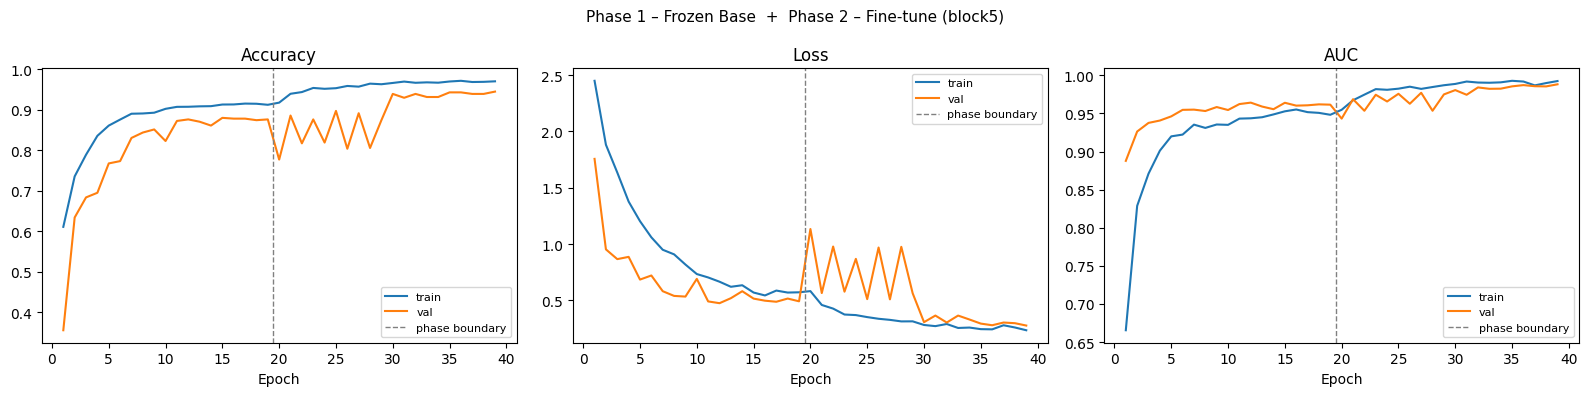

In [118]:
# ── 6a+6b: Combined training curves + threshold tuning ──────────────────────

visualization.plot_combined_training_curves(
    teacher_history,
    finetune_history,
    phase1_label="Phase 1 – Frozen Base",
    phase2_label="Phase 2 – Fine-tune (block5)",
)

# Load best checkpoints for evaluation
frozen_best   = training_utils.load_model_compat(TEACHER_CHECKPOINT_PATH)
finetune_best = training_utils.load_model_compat(FINETUNE_CHECKPOINT_PATH)
#finetune_best = load_model_compat_local(FINETUNE_CHECKPOINT_PATH)
#finetune_best   = finetune_history.model

frozen_threshold = 0.5
finetune_threshold = 0.5

# Tune decision threshold on validation set (maximises PNEUMONIA F1)
#_,   frozen_val_f1,   _, _ = training_utils.tune_threshold(frozen_best,   val_ds)
#_, finetune_val_f1, _, _ = training_utils.tune_threshold(finetune_best, val_ds)

#print(f"VGG16 Frozen   — best val F1={frozen_val_f1:.3f}  @ threshold={frozen_threshold:.2f}")
#print(f"VGG16 Finetuned — best val F1={finetune_val_f1:.3f}  @ threshold={finetune_threshold:.2f}")


In [119]:
# ── 6c: Test set metrics for both VGG16 models ──────────────────────────────

frozen_metrics,   frozen_report,   y_true, frozen_prob,   frozen_pred   = training_utils.evaluate_model(frozen_best,   test_ds, frozen_threshold)
finetune_metrics, finetune_report, y_true, finetune_prob, finetune_pred = training_utils.evaluate_model(finetune_best, test_ds, finetune_threshold)

print("── VGG16 Frozen (Phase 1 best) ──────────────────────────────")
print(f"  Accuracy:    {frozen_metrics['accuracy']:.4f}")
print(f"  AUC:         {frozen_metrics['auc']:.4f}")
print(f"  Precision:   {frozen_metrics['precision']:.4f}")
print(f"  Recall:      {frozen_metrics['recall']:.4f}")
print(f"  F1:          {frozen_metrics['f1']:.4f}")
print(f"  Threshold:   {frozen_threshold:.2f}")

print("\n── VGG16 Fine-tuned (Phase 2 best) ─────────────────────────")
print(f"  Accuracy:    {finetune_metrics['accuracy']:.4f}")
print(f"  AUC:         {finetune_metrics['auc']:.4f}")
print(f"  Precision:   {finetune_metrics['precision']:.4f}")
print(f"  Recall:      {finetune_metrics['recall']:.4f}")
print(f"  F1:          {finetune_metrics['f1']:.4f}")
print(f"  Threshold:   {finetune_threshold:.2f}")

# Save both models with metadata
save_model_with_meta(frozen_best,   "vgg16_frozen",    frozen_metrics,   teacher_history,  {"lr": 1e-4, "freeze_base": True},                    frozen_threshold)
save_model_with_meta(finetune_best, "vgg16_finetuned", finetune_metrics, finetune_history, {"lr": 1e-5, "freeze_base": False, "unfrozen": "block5"}, finetune_threshold)


── VGG16 Frozen (Phase 1 best) ──────────────────────────────
  Accuracy:    0.8654
  AUC:         0.9352
  Precision:   0.8864
  Recall:      0.9000
  F1:          0.8931
  Threshold:   0.50

── VGG16 Fine-tuned (Phase 2 best) ─────────────────────────
  Accuracy:    0.9263
  AUC:         0.9733
  Precision:   0.9195
  Recall:      0.9667
  F1:          0.9425
  Threshold:   0.50
Saved model to: /content/drive/MyDrive/saved_models/vgg16_frozen.keras
Saved metadata to: /content/drive/MyDrive/saved_models/vgg16_frozen_meta.json
Saved model to: /content/drive/MyDrive/saved_models/vgg16_finetuned.keras
Saved metadata to: /content/drive/MyDrive/saved_models/vgg16_finetuned_meta.json


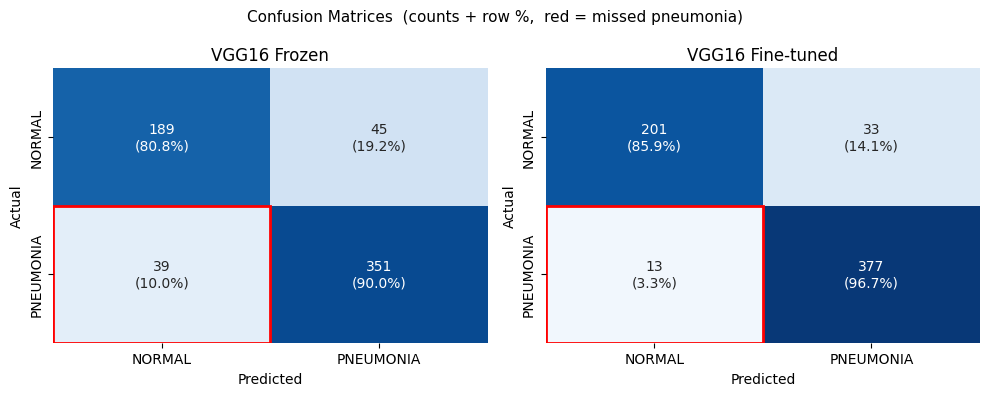

In [120]:
# ── 6d: Side-by-side confusion matrices ─────────────────────────────────────

visualization.plot_confusion_matrices_grid([
    ("VGG16 Frozen",    y_true, frozen_pred),
    ("VGG16 Fine-tuned", y_true, finetune_pred),
])


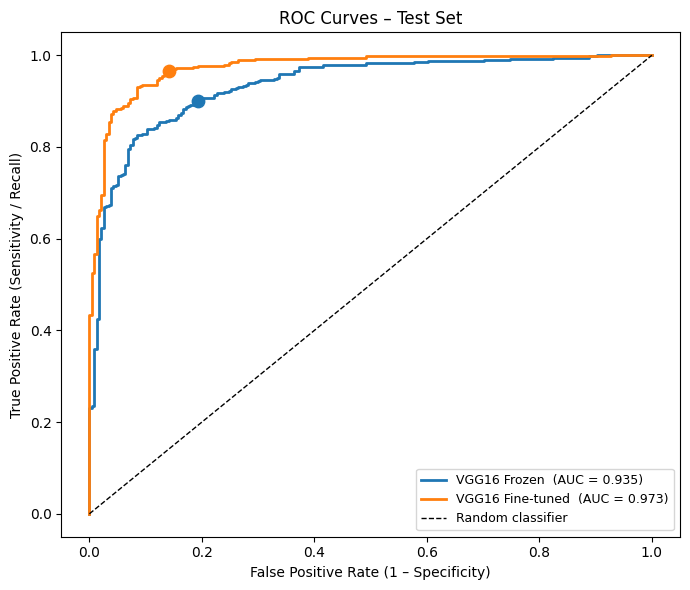

In [121]:
# ── 6e: Overlay ROC curves ───────────────────────────────────────────────────

visualization.plot_roc_curves([
    ("VGG16 Frozen",    y_true, frozen_prob,   frozen_threshold),
    ("VGG16 Fine-tuned", y_true, finetune_prob, finetune_threshold),
])


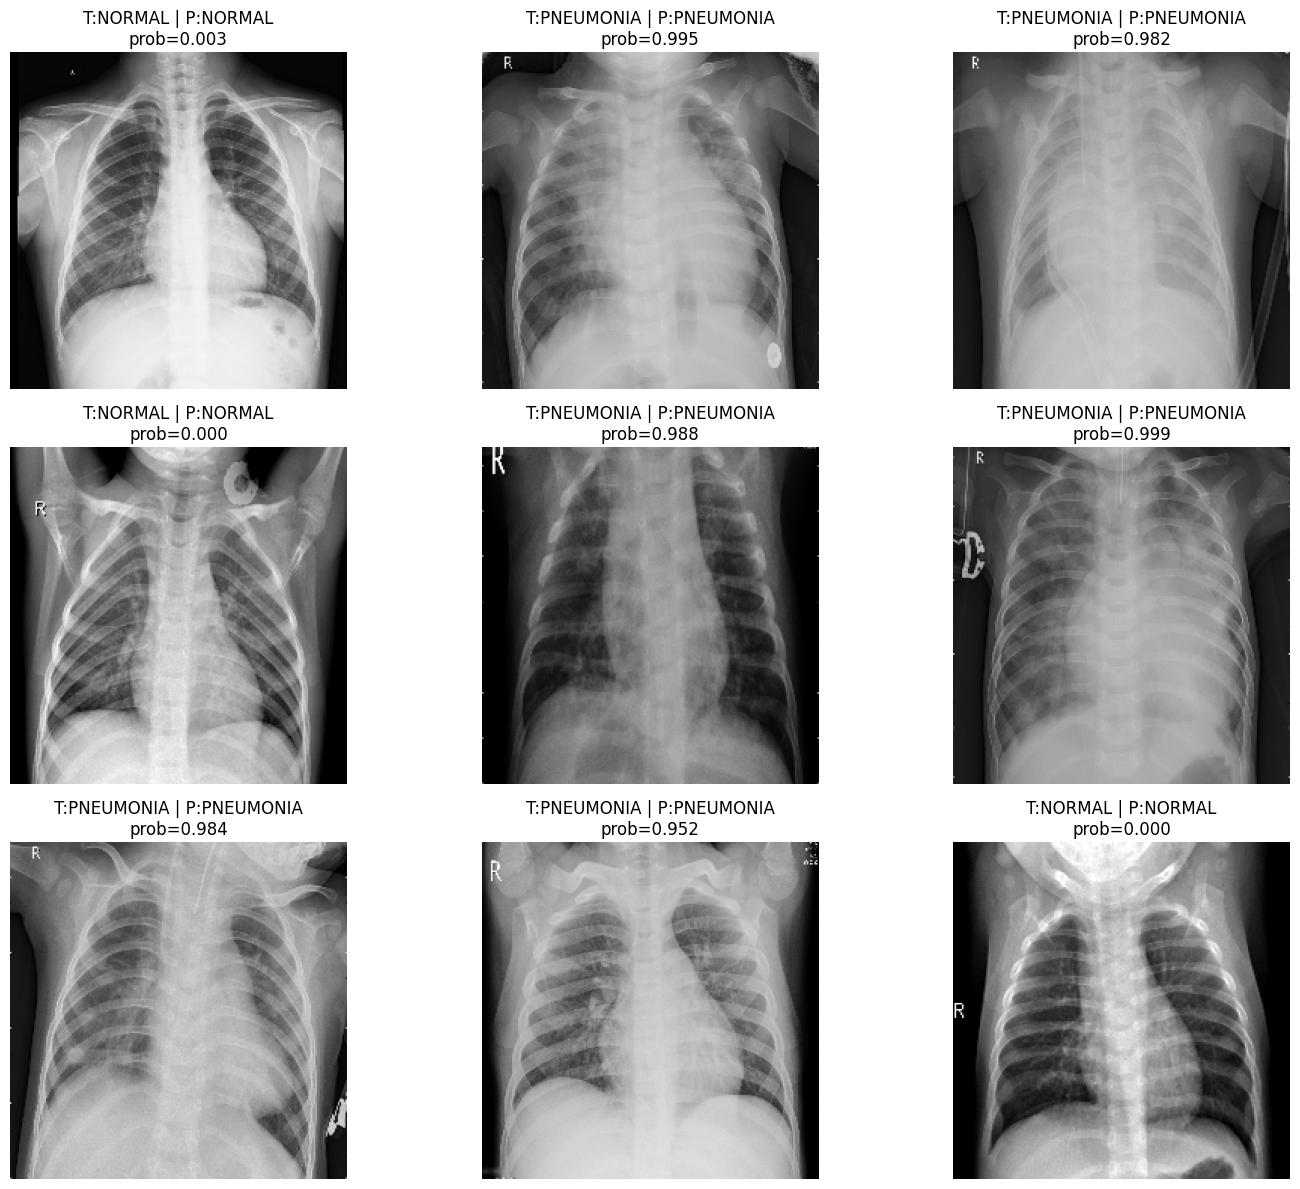

In [122]:
# ── 6g: Qualitative predictions – best model ────────────────────────────────
# Show 9 test samples from the fine-tuned model with true label, prediction,
# and confidence score.

visualization.plot_sample_predictions(finetune_best, test_ds, finetune_threshold, n=9)


<hr style="height:6px;background-color:blue;border:none;">

### Phase 3 - Final Model Comparison

=== Model Comparison vs. Paper Targets ===
                                     Test Acc  Test AUC  Precision  Recall      F1  Threshold  Trainable Params
Model                                                                                                          
Baseline CNN (without augmentation)    0.7516    0.8987     0.7213  0.9821  0.8317       0.71           1207201
Baseline CNN (with augmentation)       0.8285    0.8930     0.8393  0.8974  0.8674       0.33           1207201
Baseline CNN (tuned HP)                0.9231    0.9420     0.9091  0.9744  0.9406       0.62           9476673
VGG16 Frozen (Phase 1)                 0.8654    0.9352     0.8864  0.9000  0.8931       0.50             74369
VGG16 Fine-tuned (Phase 2)             0.9263    0.9733     0.9195  0.9667  0.9425       0.50           7153793


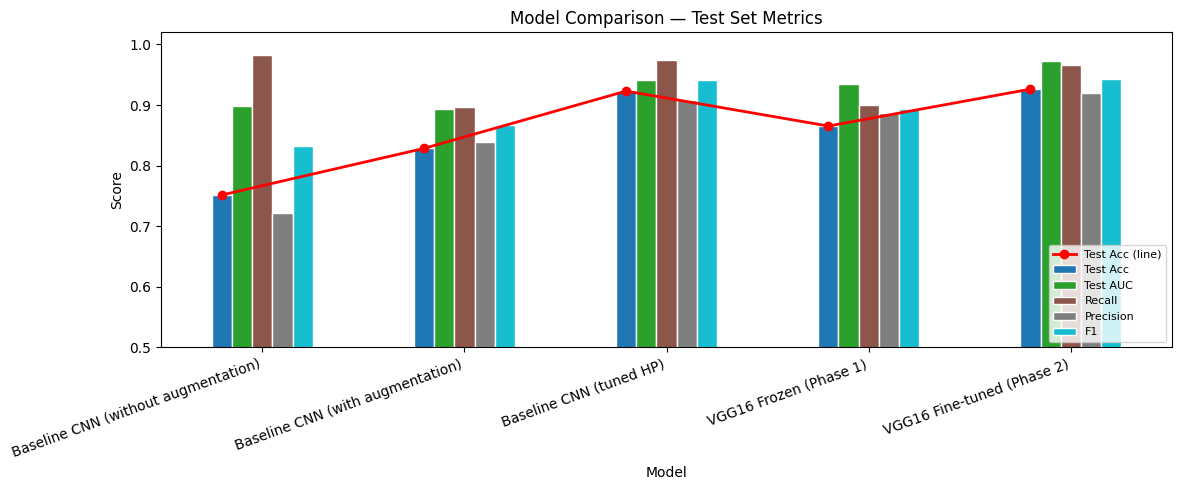

In [123]:
# ── 6f: Final comparison table vs. paper targets ────────────────────────────

import pandas as pd
import matplotlib.pyplot as plt

records = []
for model_name, label in [
    ("baseline_without_aug_cnn",       "Baseline CNN (without augmentation)"),
    ("baseline_cnn",       "Baseline CNN (with augmentation)"),
    ("baseline_cnn_tuned", "Baseline CNN (tuned HP)"),
    ("vgg16_frozen",       "VGG16 Frozen (Phase 1)"),
    ("vgg16_finetuned",    "VGG16 Fine-tuned (Phase 2)"),
]:
    meta = training_utils.load_model_meta(SAVE_DIR, model_name)
    if meta is None:
        continue
    m = meta["metrics"]
    records.append({
        "Model":      label,
        "Test Acc":   round(m.get("accuracy", 0), 4),
        "Test AUC":   round(m.get("auc", 0), 4),
        "Precision":  round(m.get("precision", 0), 4),
        "Recall":     round(m.get("recall", 0), 4),
        "F1":         round(m.get("f1", 0), 4),
        "Threshold":  round(meta.get("threshold", 0), 2),
        "Trainable Params": meta.get("model_params", {}).get("trainable", "—"),
    })

comparison_df = pd.DataFrame(records).set_index("Model")

# ── Styled table ─────────────────────────────────────────────────────────────
metric_cols = ["Test Acc", "Test AUC", "Precision", "Recall", "F1"]
numeric_df  = comparison_df[metric_cols].apply(pd.to_numeric, errors="coerce")

def _highlight(col):
    best_val = col.dropna().max()
    colors = []
    for val in col:
        if pd.isna(val):
            colors.append("")
        elif val == best_val:
            colors.append("background-color: #c6efce; font-weight: bold")
        else:
            colors.append("")
    return colors

def _mark_vs_paper(df):
    """Add check/cross suffix to metric cells based on paper target values."""
    paper_targets = {
        "Test Acc":  0.910,
        "Precision": 0.899,
        "Recall":    0.964,
        "F1":        0.931,
    }
    display = df.copy().astype(str)
    for col, target in paper_targets.items():
        if col not in display.columns:
            continue
        for idx in display.index:
            try:
                val = float(df.loc[idx, col])
                if "Paper" in str(idx):
                    continue
                symbol = " ✓" if val >= target else " ✗"
                display.loc[idx, col] = f"{val:.4f}{symbol}"
            except (ValueError, TypeError):
                pass
    return display

display_df = _mark_vs_paper(numeric_df)
print("=== Model Comparison vs. Paper Targets ===")
print(comparison_df[metric_cols + ["Threshold", "Trainable Params"]].to_string())

# ── Bar chart: AUC / Recall / Precision / F1 ─────────────────────────────────

plot_df = comparison_df.copy()

ax = plot_df[["Test Acc","Test AUC", "Recall", "Precision", "F1"]].plot(
    kind="bar", figsize=(12, 5), colormap="tab10", edgecolor="white"
)

x = ax.patches[0:len(plot_df)]  # first group = Test Acc bars
x_pos = [p.get_x() + p.get_width()/2 for p in x]

ax.plot(
    x_pos,
    plot_df["Test Acc"],
    color="red",
    marker="o",
    linewidth=2,
    label="Test Acc (line)"
)

# Draw horizontal reference lines for paper targets
colors_map = {"Recall": "tab:orange", "Precision": "tab:green", "F1": "tab:red"}

ax.set_ylim(0.5, 1.02)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Test Set Metrics")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


In [124]:
histories = {}

for model_name, label in [
    ("baseline_without_aug_cnn", "Baseline CNN (without augmentation)"),
    ("baseline_cnn", "Baseline CNN (with augmentation)"),
    ("baseline_cnn_tuned", "Baseline CNN (tuned HP)"),
    ("vgg16_frozen", "VGG16 Frozen (Phase 1)"),
    ("vgg16_finetuned", "VGG16 Fine-tuned (Phase 2)"),
]:
    meta = training_utils.load_model_meta(SAVE_DIR, model_name)
    if meta is None:
        continue
    histories[label] = meta["history"]

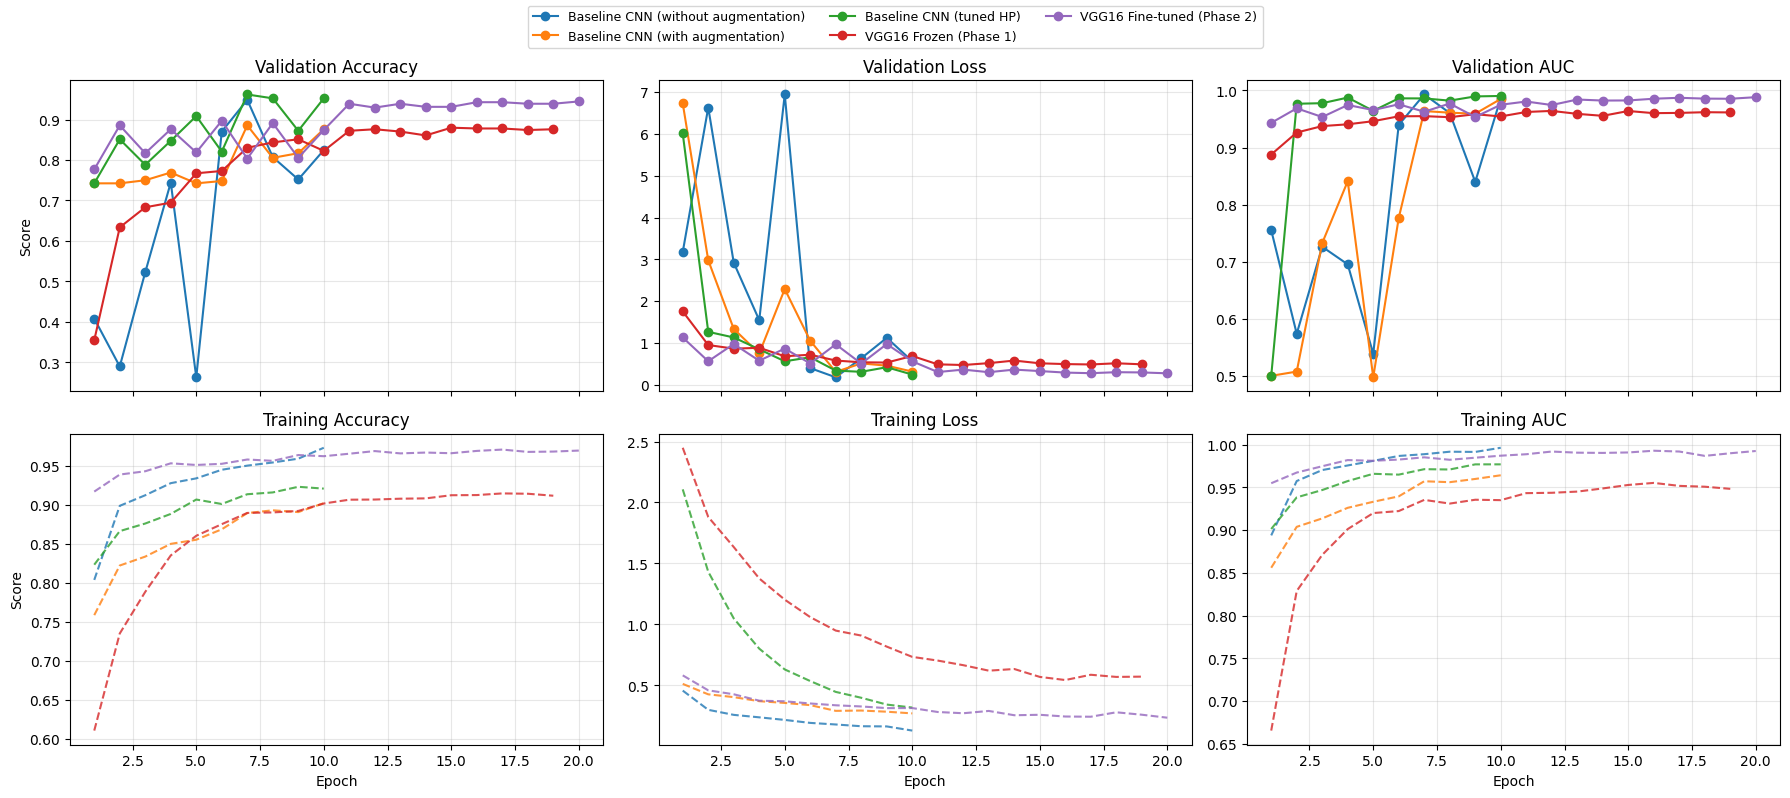

In [125]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

metrics = [
    ("accuracy", "val_accuracy", "Accuracy"),
    ("loss", "val_loss", "Loss"),
    ("auc", "val_auc", "AUC"),
]

# ── Top row: Validation ─────────────────────────────────────────────
for col, (train_key, val_key, title) in enumerate(metrics):
    ax = axes[0, col]

    for label, hist in histories.items():
        epochs = range(1, len(hist[val_key]) + 1)
        ax.plot(epochs, hist[val_key], marker='o', label=label)

    ax.set_title(f"Validation {title}")
    ax.grid(alpha=0.3)

# ── Bottom row: Training ────────────────────────────────────────────
for col, (train_key, val_key, title) in enumerate(metrics):
    ax = axes[1, col]

    for label, hist in histories.items():
        epochs = range(1, len(hist[train_key]) + 1)
        ax.plot(epochs, hist[train_key], linestyle='--', alpha=0.8, label=label)

    ax.set_title(f"Training {title}")
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)

# ── Labels & legend ─────────────────────────────────────────────────
axes[0, 0].set_ylabel("Score")
axes[1, 0].set_ylabel("Score")

# Put legend once (cleaner)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

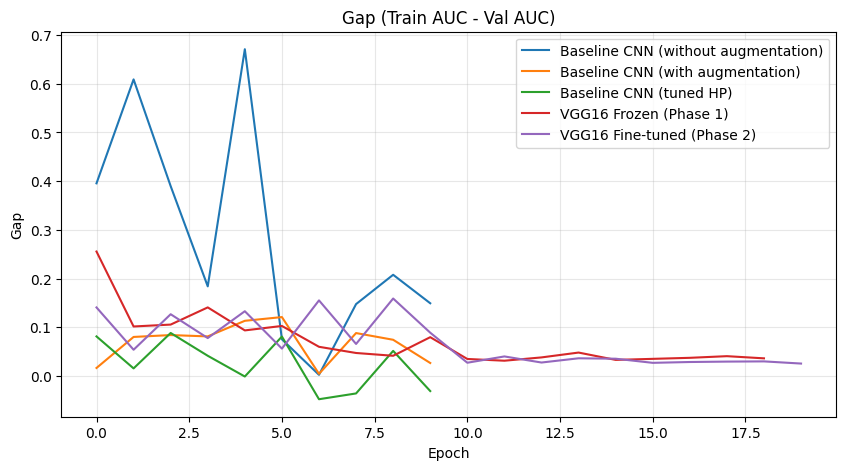

In [126]:
plt.figure(figsize=(10,5))

for label, hist in histories.items():
    gap = [t - v for t, v in zip(hist["accuracy"], hist["val_accuracy"])]
    plt.plot(gap, label=label)

plt.title("Gap (Train AUC - Val AUC)")
plt.xlabel("Epoch")
plt.ylabel("Gap")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)